Imports

In [12]:
import generate_training
import Multi_loop
import time
from glob import glob
from LightPipes import * 
import torch
import pickle as pkl
import json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from mode_classifier import ResNet, ResidualBlock
import modes
from tqdm import tqdm as tqdm
from pickle_Dataset import pickle_Dataset
import gc
from torch.cuda.amp import autocast, GradScaler

Customize Training data

In [13]:
mode_params = [
    {'mode': [0,0], 'LG': False, 'angle': 0, 'diameter': [150*um, 250*um]},
    {'mode': [0,1], 'LG': False, 'angle': 155 - 90, 'diameter': False}, 
    {'mode': [0,4], 'LG': False, 'angle': 70+90, 'diameter': False}, 
    {'mode': [0,6], 'LG': False, 'angle': 70+90, 'diameter': False},
    {'mode': [0,9], 'LG': False, 'angle': 70+90, 'diameter': False}  
]

: 

In [10]:
# For models for confidence of each mode use modes.mode_func
# For model for bec or multi mode use modes.bec_multi
test_ims = generate_training.generate_data(
    10, 2500*um, 500, mode_params, [150*um, 200*um],
    fringe_size = [0.3,0.6], save=False, mult_las_split=0.5, 
    mode_func=modes.bec_multi)

 10%|█         | 1/10 [00:01<00:10,  1.15s/it]

!


 30%|███       | 3/10 [00:02<00:05,  1.22it/s]

!


 70%|███████   | 7/10 [00:04<00:01,  1.97it/s]

!


 80%|████████  | 8/10 [00:04<00:00,  2.05it/s]

!


100%|██████████| 10/10 [00:05<00:00,  1.75it/s]


tensor([[0., 1.]])


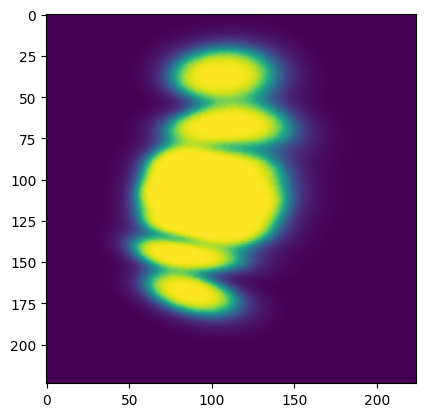

In [11]:
img = test_ims[0]
print(img[1])
plt.imshow(img[0])
plt.show()


Generate Training Data

In [ ]:
save = True
save_dir = r'C:\Users\Pouis\Documents\Uni Shit\Masters\Training Images'
num_threads = 14
ims = generate_training.generate_data_multithreaded(num_threads, 30000 // num_threads, 2500*um, 
                                                    500, generate_training.modelist, [160*um, 210*um], 
                                                    fringe_size=[0.5, 0.8], save=save, 
                                                    mult_las_split=0, save_dir=save_dir)




Set up model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
classes = len(generate_training.modelist) # for confidence
classes = 1 # for bec_multi
epochs = 50
criterion = torch.nn.CrossEntropyLoss()
learning_rate = 0.0001
val_split = 0.2
batch_size = 128
best_accuracy = 0.0 

save_path = r'MultiMode Analysis\Models\Apr26_Res_Class_'

with open(save_path + 'mode_parameters.json', 'w') as f:
    json.dump(mode_params, f)

transform = v2.Compose([v2.ToTensor(), v2.Resize((224,224), antialias=True), v2.Normalize((0.5,), (
        0.5,))])


Create Training dataset

In [ ]:
# Creates dataset of all images
train_dataset = pickle_Dataset(root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\Training Images', transforms = transform)

# splits dataset into test and training data
numTrainSamp = round(len(train_dataset) * (1 - val_split))
numValSamp = len(train_dataset) - numTrainSamp
(train_dataset, validate_dataset) = torch.utils.data.random_split(train_dataset, [int(numTrainSamp), int(numValSamp)],
                                                                                generator=None)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset=validate_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

Train Model

In [ ]:
for i in tqdm(range(classes), leave=True):
    model = ResNet(ResidualBlock, [2, 2, 2, 2], 2)

    # append_dropout(model)
    history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_loss": []
    }
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum = 0)
    # runs Training loop
    model, history = Multi_loop.Training(model, epochs, i, optimizer, 
                                         train_loader, val_loader, history, 
                                         criterion=criterion, save_path=save_path)

    with open(save_path + f'{i}_' + 'history.json', 'w') as f:
        json.dump(history, f)

    del model

Plot Histories

In [ ]:
hist_files = glob(save_path + '*history*')

from power_length_analysis import grid_plot
from math import ceil

ncols = 3
fig, axes, gs = grid_plot(classes, ncols = ncols, nrows = ceil(classes/ncols), wspace=0.5)

for i, (hist, mp) in enumerate(zip(hist_files, mode_params)):
    hist = json.load(f)
    l1 = axes[i].plot(hist['train_accuracy'], label = 'Training Accuracy')
    l2 = axes[i].plot(hist['val_accuracy'], label = 'Validation Accuracy')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes.set_title(mp['mode'])
fig.legend(handles=[l1,l2])
fig.suptitle('Training Accuracies')
plt.show()

ncols = 3
fig, axes, gs = grid_plot(classes, ncols = ncols, nrows = ceil(classes/ncols), wspace=0.5)

for i, (hist, mp) in enumerate(zip(hist_files, mode_params)):
    hist = json.load(f)
    l1 = axes[i].plot(hist['train_loss'], label = 'Training Loss')
    l2 = axes[i].plot(hist['val_loss'], label = 'Validation Loss')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes.set_title(mp['mode'])
fig.legend(handles=[l1,l2])
fig.suptitle('Training Losses')
plt.show()

